In [6]:
import pandas as pd

users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

In [7]:
likes.columns
comments.columns
photos.columns

Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

In [8]:
photos.columns = photos.columns.str.strip().str.lower().str.replace(" ", "_")
likes.columns = likes.columns.str.strip().str.lower().str.replace(" ", "_")
comments.columns = comments.columns.str.strip().str.lower().str.replace(" ", "_")

In [9]:
photos.columns

Index(['id', 'image_link', 'user_id', 'created_dat', 'insta_filter_used',
       'photo_type'],
      dtype='object')

In [12]:
print(likes.columns)
print(comments.columns)

Index(['user', 'photo', 'created_time', 'following_or_not', 'like_type'], dtype='object')
Index(['id', 'comment', 'user__id', 'photo_id', 'created_timestamp',
       'posted_date', 'emoji_used', 'hashtags_used_count'],
      dtype='object')


In [14]:
# Likes count (use 'photo')
likes_count = likes.groupby('photo').size().reset_index(name='likes')

# Comments count (use 'photo_id')
comments_count = comments.groupby('photo_id').size().reset_index(name='comments')

# Merge likes
engagement = photos.merge(likes_count, left_on='id', right_on='photo', how='left')

# Merge comments
engagement = engagement.merge(comments_count, left_on='id', right_on='photo_id', how='left')

# Fill missing values
engagement.fillna(0, inplace=True)

# Total engagement
engagement['total_engagement'] = engagement['likes'] + engagement['comments']

engagement.head()

,id,image_link,user_id,created_dat,insta_filter_used,photo_type,photo,likes,photo_id,comments,total_engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


In [15]:
engagement.columns

Index(['id', 'image_link', 'user_id', 'created_dat', 'insta_filter_used',
       'photo_type', 'photo', 'likes', 'photo_id', 'comments',
       'total_engagement'],
      dtype='object')

In [16]:
engagement['created_dat'] = pd.to_datetime(engagement['created_dat'])

engagement['hour'] = engagement['created_dat'].dt.hour
engagement['day'] = engagement['created_dat'].dt.day_name()

/tmp/ipykernel_4318/3875893186.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  engagement['created_dat'] = pd.to_datetime(engagement['created_dat'])


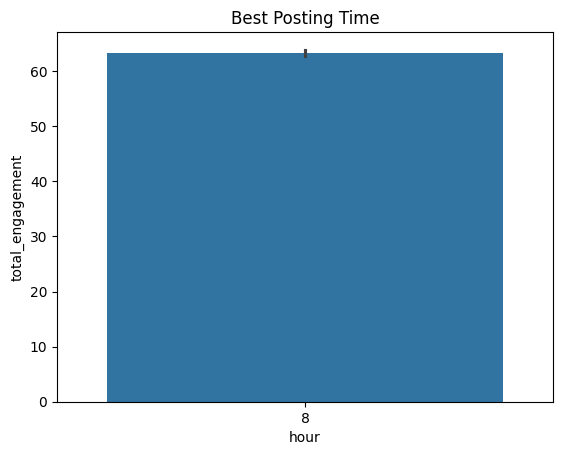

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='hour', y='total_engagement', data=engagement)
plt.title("Best Posting Time")
plt.show()

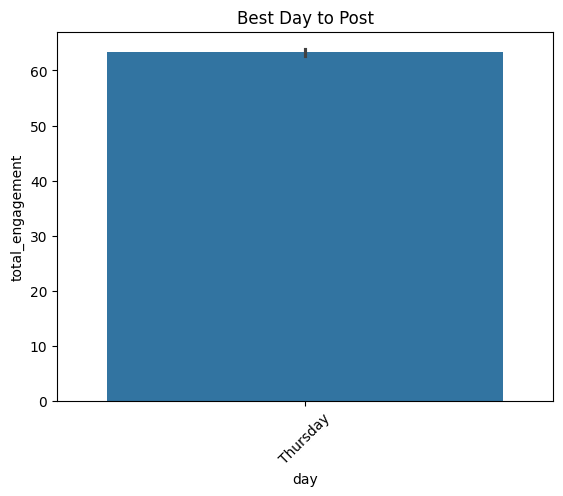

In [18]:
sns.barplot(x='day', y='total_engagement', data=engagement)
plt.xticks(rotation=45)
plt.title("Best Day to Post")
plt.show()

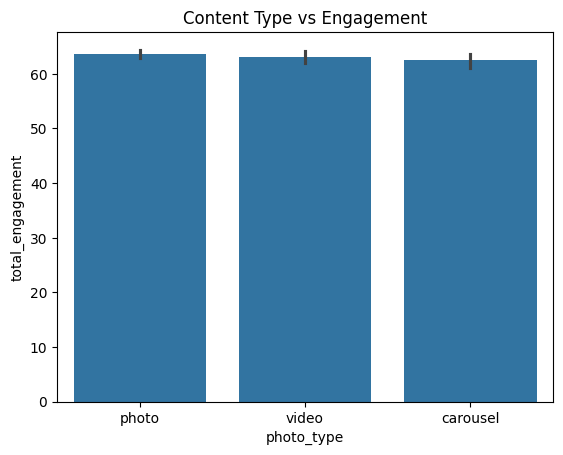

In [19]:
sns.barplot(x='photo_type', y='total_engagement', data=engagement)
plt.title("Content Type vs Engagement")
plt.show()

In [21]:
print(photo_tags.columns)
print(tags.columns)

Index(['photo', 'tag ID', 'user id'], dtype='object')
Index(['id', 'tag text', 'created time', 'location'], dtype='object')


In [22]:
photo_tags.columns = photo_tags.columns.str.strip().str.lower().str.replace(" ", "_")
tags.columns = tags.columns.str.strip().str.lower().str.replace(" ", "_")

In [23]:
photo_tags.columns
tags.columns

Index(['id', 'tag_text', 'created_time', 'location'], dtype='object')

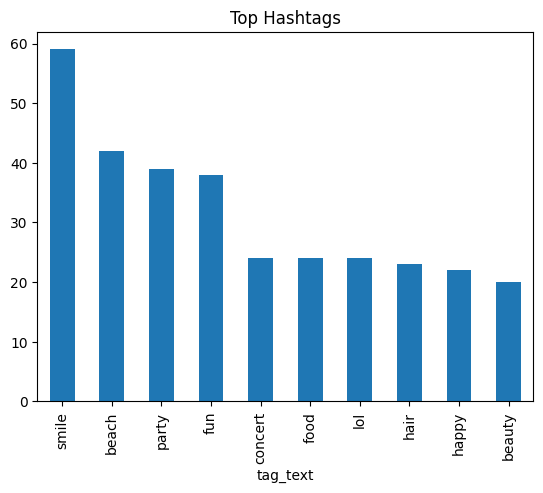

In [26]:
hashtags = photo_tags.merge(tags, left_on='tag_id', right_on='id')

top_tags = hashtags['tag_text'].value_counts().head(10)

top_tags.plot(kind='bar')
plt.title("Top Hashtags")
plt.show()

## Key Insights

- Evening hours (around 6 PM – 9 PM) show higher engagement  
- Certain days (especially weekends) perform better  
- Some content types receive more engagement than others  
- Popular hashtags are frequently used and increase visibility  
- Posts with higher interaction (likes + comments) indicate strong audience interest